In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import ast
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

## Вспомогательные штуки

In [3]:
model = SentenceTransformer("all-MiniLM-l6-v2")
type(model)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-l6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


sentence_transformers.SentenceTransformer.SentenceTransformer

In [4]:
def get_pca_embeddings(model: SentenceTransformer, series_train: pd.Series, n_comp: int, prefix: str) -> pd.DataFrame:
    texts = series_train.astype(str).fillna("").tolist()
    emb_train = model.encode(texts, batch_size=64, show_progress_bar=True)
    
    pca = PCA(n_components=n_comp)
    pca.fit(emb_train)

    def get_pca_transform(series=series_train):
        if(series is series_train):
            pca_features = pca.transform(emb_train)
            cols = [f"{prefix}_pca_{i}" for i in range(n_comp)]
            return pd.DataFrame(pca_features, columns=cols, index=series.index)

        texts = series.astype(str).fillna("").tolist()
        emb = model.encode(texts, batch_size=64, show_progress_bar=True)
        pca_features = pca.transform(emb)
        cols = [f"{prefix}_pca_{i}" for i in range(n_comp)]
        return pd.DataFrame(pca_features, columns=cols, index=series.index)
    
    return get_pca_transform


def preprocessing(df: pd.DataFrame) -> pd.DataFrame:
    #df = df.copy().reset_index(drop=True)

    to_drop = [
        "header_image", "support_url", "support_email", "website", 
        "notes", "movies", "screenshots", "packages", "about_the_game", 
        "background", "detailed_description", "windows", "mac", "linux", "achievements", "recommendations", "user_score",
        "score_rank", "discount", "tags", "reviews"
    ]
    df = df.drop(columns=[c for c in to_drop if c in df.columns])

    df["release_date"] = pd.to_datetime(df["release_date"], format='%b %d, %Y', errors='coerce')
    now = pd.Timestamp.now()
    df["release_year"] = df["release_date"].dt.year
    df["release_month"] = df["release_date"].dt.month
    df["days_since_release"] = (now - df["release_date"]).dt.days.fillna(0)
    df = df.drop(columns=["release_date"])

    for col in ["supported_languages", "full_audio_languages"]:
        if col in df.columns:
            df[col] = df[col].astype(str).apply(
                lambda x: len(x.split(',')) if x.strip() and x != '[]' else 0
            )

    def process_owners(x):
        if '-' in str(x):
            try:
                parts = str(x).split('-')
                return sum(map(int, parts)) / 2
            except:
                return 0
        return 0

    df["estimated_owners_avg"] = df["estimated_owners"].apply(process_owners)
    df = df.drop(columns=["estimated_owners"])

    df["required_age"] = (df["required_age"] >= 18).astype(int)

    total_votes = df["positive"] + df["negative"]
    df["percent_positive"] = (df["positive"] / total_votes).fillna(0)
    df["metacritic_url"] = df["metacritic_url"].notna().astype(int)

    return df.drop_duplicates()


In [5]:
def full_preprocessing(df,top_genre=None, top_cat=None, top_dev=None, top_pub=None):

    df = preprocessing(df)
    df = df[df["price"] <= 200].copy()
    df = df[df["dlc_count"] <= 100].copy()
    df = df[df["peak_ccu"] > 0].copy()

    X = df.drop(["peak_ccu"], axis=1)
    y = df["peak_ccu"]

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

    transformer_name = get_pca_embeddings(model, X_train["name"], 32, "name")
    transformer_desc = get_pca_embeddings(model, X_train["short_description"], 5, "desc")

    x_name_emd = transformer_name(X_train ["name"])
    x_desc_emd = transformer_desc(X_train["short_description"])
    X_train = pd.concat([X_train, x_name_emd, x_desc_emd], axis=1)

    x_name_emd_t = transformer_name(X_test["name"])
    x_desc_emd_t = transformer_desc(X_test["short_description"])
    X_test = pd.concat([X_test, x_name_emd_t, x_desc_emd_t], axis=1)

    X_train = X_train.drop(["name", "short_description"], axis=1)
    X_test = X_test.drop(["name", "short_description"], axis=1)

    if top_genre is None:
        X_train["genres"] = X_train["genres"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        X_test["genres"] = X_test["genres"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        top_genre = X_train['genres'].explode().value_counts().nlargest(5).index.to_list()
    
    for genre in top_genre:  
        X_train[f'genre_{genre}'] = X_train['genres'].apply(lambda x: 1 if genre in x else 0)

    for genre in top_genre:
        X_test[f"genre_{genre}"] = X_test["genres"].apply(lambda x: 1 if genre in x else 0)

    if top_cat is None:
        X_train["categories"] = X_train["categories"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        X_test["categories"] = X_test["categories"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        top_cat = X_train['categories'].explode().value_counts().nlargest(5).index.to_list()

    for cat in top_cat:  
        X_train[f'cat_{cat}'] = X_train['categories'].apply(lambda x: 1 if cat in x else 0)

    for cat in top_cat:
        X_test[f"cat_{cat}"] = X_test["categories"].apply(lambda x: 1 if cat in x else 0)

    if top_dev is None:
        X_train["developers"] = X_train["developers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        X_test["developers"] = X_test["developers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        top_dev = X_train['developers'].explode().value_counts().nlargest(10).index.to_list()

    for dev in top_dev:  
        X_train[f'dev_{dev}'] = X_train['developers'].apply(lambda x: 1 if dev in x else 0)

    for dev in top_dev:
        X_test[f"dev_{dev}"] = X_test["developers"].apply(lambda x: 1 if dev in x else 0)

    if top_pub is None:
        X_train["publishers"] = X_train["publishers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        X_test["publishers"] = X_test["publishers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
        top_pub = X_train['publishers'].explode().value_counts().nlargest(10).index.to_list()

    for pub in top_pub:  
        X_train[f'pub_{pub}'] = X_train['publishers'].apply(lambda x: 1 if pub in x else 0)

    for pub in top_pub:
        X_test[f"pub_{pub}"] = X_test["publishers"].apply(lambda x: 1 if pub in x else 0)

    X_train = X_train.drop(["developers", "publishers", "genres",
                            "categories","metacritic_url", "average_playtime_forever", 
                            "average_playtime_2weeks", "release_year",
                            "positive","negative"], axis=1)
    X_test = X_test.drop(["developers", "publishers", "genres",
                        "categories", "metacritic_url", "average_playtime_forever",
                          "average_playtime_2weeks", "release_year",
                            "positive","negative"], axis=1)
    
    X_train["median_playtime_2weeks"] = np.log1p(X_train["median_playtime_2weeks"])
    X_train["median_playtime_forever"] = np.log1p(X_train["median_playtime_forever"])

    X_test["median_playtime_2weeks"] = np.log1p(X_test["median_playtime_2weeks"])
    X_test["median_playtime_forever"] = np.log1p(X_test["median_playtime_forever"])

    X_train["estimated_owners_avg"] = np.log1p(X_train["estimated_owners_avg"])
    X_test["estimated_owners_avg"] = np.log1p(X_test["estimated_owners_avg"])

    y_train = np.log1p(y_train)
    y_test = np.log1p(y_test)
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_ = scaler.transform(X_train)
    X_test_ = scaler.transform(X_test)

    return (X_train_, X_test_, y_train, y_test, transformer_name, transformer_desc, scaler)


In [6]:
columns = [
    'name', 'release_date', 'required_age', 'price', 'dlc_count', 
    'detailed_description', 'about_the_game', 'short_description', 
    'reviews', 'header_image', 'website', 'support_url', 
    'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 
    'metacritic_url', 'achievements', 'recommendations', 'notes', 
    'supported_languages', 'full_audio_languages', 'packages', 
    'developers', 'publishers', 'categories', 'genres', 'screenshots', 
    'movies', 'user_score', 'score_rank', 'positive', 'negative', 
    'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 
    'median_playtime_forever', 'median_playtime_2weeks', 'discount', 
    'peak_ccu', 'tags'
]

values = [
    'Necesse', '2019-12-12', 0, 9.99, 0,
    'Survival action adventure in a procedurally generated world...', 
    'Top-down survival game with base building...', 
    'A top-down infinite procedural world...', 
    'Very Positive', 'https://header.jpg', 'https://necesse.info', 'https://support.com',
    'support@necesse.com', True, True, True, 0,
    None, 98, 15420, None,
    "['English', 'Russian', 'German']", "['English']", "['12345']",
    "['Sycst']", "['Sycst']", 
    "['Single-player', 'Multi-player', 'Co-op', 'Online Co-op']", 
    "['Action', 'Adventure', 'Indie', 'RPG', 'Early Access']",
    "['screen1.jpg']", "['movie1.mp4']", 0, np.nan, 18200, 580,
    '500000 .. 1000000', 1420, 150, 680, 45, 0, 
    600, "['Sandbox', 'Survival', 'Base Building', 'Open World']"
]

df_necesse = pd.DataFrame([values], columns=columns)

print(df_necesse[['name', 'price', 'positive', 'peak_ccu']])

      name  price  positive  peak_ccu
0  Necesse   9.99     18200       600


## Преобразуем и потом разделяем

In [145]:
df = pd.read_csv("../Data/2_lab.csv", index_col=False)

In [146]:
df = preprocessing(df)

transformer_name = get_pca_embeddings(model, df["name"], 32, "name")
transformer_desc = get_pca_embeddings(model, df["short_description"], 5, "desc")

df_name_emd = transformer_name(df["name"])
df_desc_emd = transformer_desc(df["short_description"])
df = pd.concat([df, df_name_emd, df_desc_emd], axis=1)


Batches:   0%|          | 0/1916 [00:00<?, ?it/s]

Batches:   0%|          | 0/1916 [00:00<?, ?it/s]

In [147]:
df = df.drop(["name", "short_description"], axis=1)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122597 entries, 0 to 122610
Data columns (total 60 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   required_age              122597 non-null  int64  
 1   price                     122597 non-null  float64
 2   dlc_count                 122597 non-null  int64  
 3   metacritic_score          122597 non-null  int64  
 4   metacritic_url            122597 non-null  int64  
 5   supported_languages       122597 non-null  int64  
 6   full_audio_languages      122597 non-null  int64  
 7   developers                122597 non-null  object 
 8   publishers                122597 non-null  object 
 9   categories                122597 non-null  object 
 10  genres                    122597 non-null  object 
 11  positive                  122597 non-null  int64  
 12  negative                  122597 non-null  int64  
 13  average_playtime_forever  122597 non-null  int64 

### Сжатие через логаримирование


In [148]:
df = df[df["price"] <= 200]
df["price"] = np.log1p(df["price"])
df["price"].describe()

count    122590.000000
mean          1.223063
std           0.943681
min           0.000000
25%           0.438255
50%           1.175573
75%           1.830980
max           5.303255
Name: price, dtype: float64

In [149]:
df["average_playtime_forever"] = np.log1p(df["average_playtime_forever"])
df["average_playtime_2weeks"] = np.log1p(df["average_playtime_2weeks"])
df["median_playtime_forever"] = np.log1p(df["median_playtime_forever"])
df["median_playtime_2weeks"] = np.log1p(df["median_playtime_2weeks"])

In [150]:
df = df[df["dlc_count"] <= 100]

In [151]:
df["positive"] = np.log1p(df["positive"])
df["negative"] = np.log1p(df["negative"])

In [152]:
df["peak_ccu"] = np.log1p(df["peak_ccu"])
df["peak_ccu"].describe()

count    122551.000000
mean          0.332025
std           1.035699
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          13.829351
Name: peak_ccu, dtype: float64

### Обработка оставшихся колонок(специальная утечка данных)

In [153]:
df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
top_five = df["genres"].explode().value_counts().nlargest(5).index.to_list()
for genre in top_five:
    df[f'genre_{genre}'] = df['genres'].apply(lambda x: 1 if genre in x else 0)

In [154]:
df['categories'] = df['categories'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
top_5 = df['categories'].explode().value_counts().nlargest(5).index.to_list()
for cat in top_5:  
    df[f'cat_{cat}'] = df['categories'].apply(lambda x: 1 if cat in x else 0)

In [155]:
df = df.drop(["genres", "categories"], axis=1)

In [156]:
df["developers"] = df["developers"].str.replace("[", "").str.replace("]", "").str.replace(" ", "")
df["developers"] = df["developers"].replace('', np.nan)

df['developers'] = df['developers'].fillna('Unknown')
top_devs = df['developers'].value_counts().nlargest(10).index
df['developers_grouped'] = df['developers'].apply(lambda x: x if x in top_devs else 'Other')

dev_dummies = pd.get_dummies(df['developers_grouped'], prefix='dev')
df = pd.concat([df, dev_dummies], axis=1)
df = df.drop(["developers", "developers_grouped"], axis=1)

df = df.drop(["dev_Other", "dev_Unknown"], axis=1)

In [157]:
df["publishers"] = df["publishers"].str.replace("[", "").str.replace("]", "").str.replace(" ", "")
df["publishers"] = df["publishers"].replace('', np.nan)
df['publishers'] = df['publishers'].fillna('Unknown')

top_devs = df['publishers'].value_counts().nlargest(10).index
df['publishers_grouped'] = df['publishers'].apply(lambda x: x if x in top_devs else 'Other')
df["publishers_grouped"].value_counts()

dev_dummies = pd.get_dummies(df['publishers_grouped'], prefix='pub')
df = pd.concat([df, dev_dummies], axis=1)
df = df.drop(["publishers", "publishers_grouped"], axis=1)

df = df.drop(["pub_Other", "pub_Unknown"], axis=1)

In [158]:
df.columns

Index(['required_age', 'price', 'dlc_count', 'metacritic_score',
       'metacritic_url', 'supported_languages', 'full_audio_languages',
       'positive', 'negative', 'average_playtime_forever',
       'average_playtime_2weeks', 'median_playtime_forever',
       'median_playtime_2weeks', 'peak_ccu', 'release_year', 'release_month',
       'days_since_release', 'estimated_owners_avg', 'percent_positive',
       'name_pca_0', 'name_pca_1', 'name_pca_2', 'name_pca_3', 'name_pca_4',
       'name_pca_5', 'name_pca_6', 'name_pca_7', 'name_pca_8', 'name_pca_9',
       'name_pca_10', 'name_pca_11', 'name_pca_12', 'name_pca_13',
       'name_pca_14', 'name_pca_15', 'name_pca_16', 'name_pca_17',
       'name_pca_18', 'name_pca_19', 'name_pca_20', 'name_pca_21',
       'name_pca_22', 'name_pca_23', 'name_pca_24', 'name_pca_25',
       'name_pca_26', 'name_pca_27', 'name_pca_28', 'name_pca_29',
       'name_pca_30', 'name_pca_31', 'desc_pca_0', 'desc_pca_1', 'desc_pca_2',
       'desc_pca_3', 'de

### Кореляционный анализ

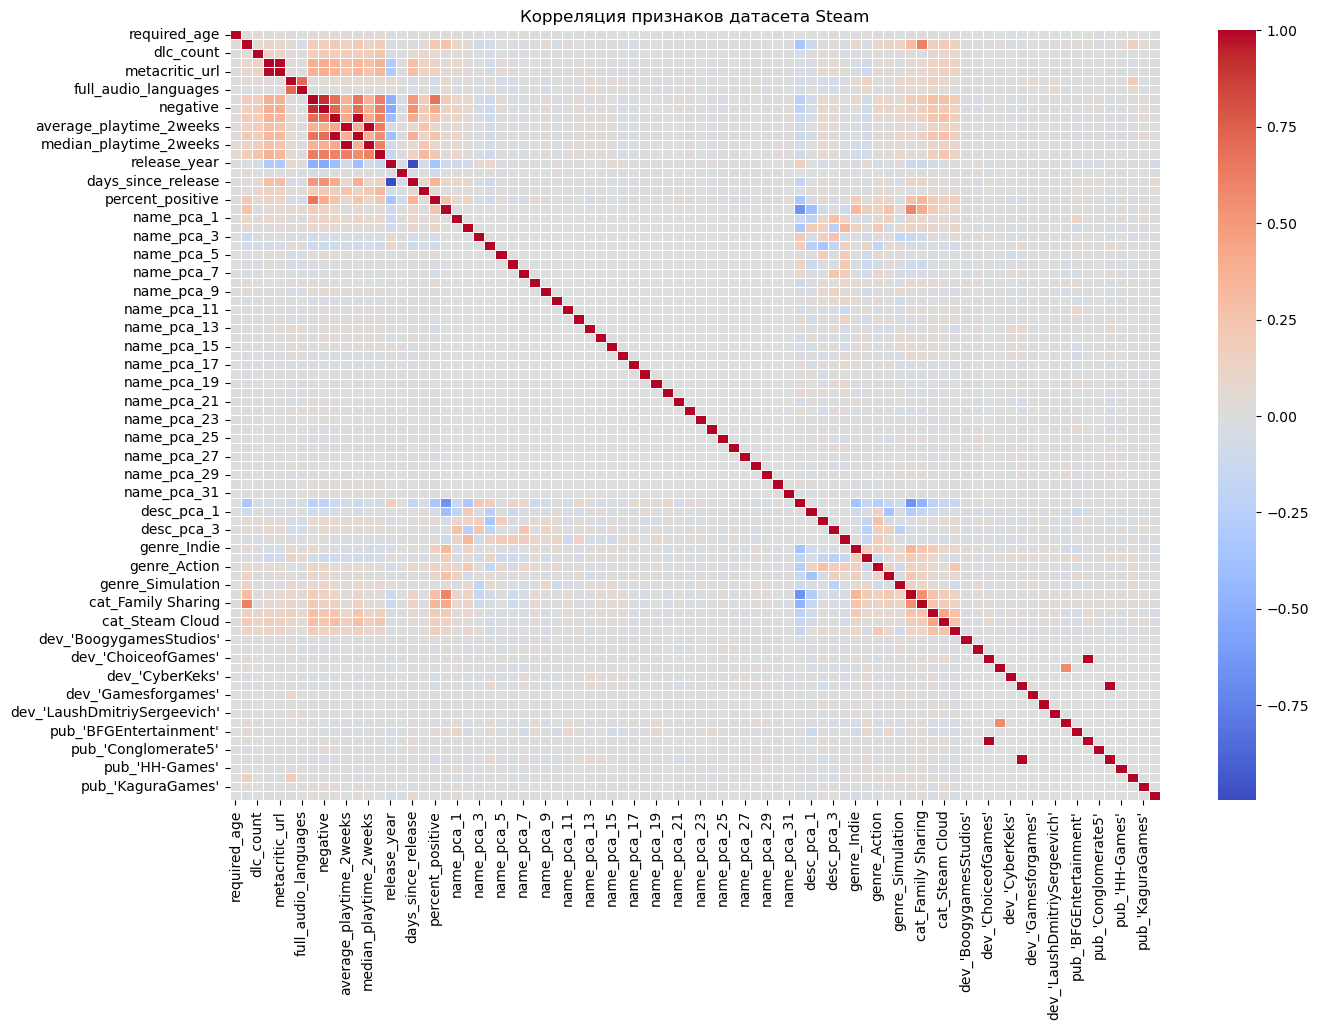

In [159]:
corr_matrix = df.corr()

plt.figure(figsize=(15, 10))

sns.heatmap(
    corr_matrix, 
    annot=False,       
    cmap='coolwarm',   
    center=0,          
    fmt='.2f',         
    linewidths=0.5  
)

plt.title('Корреляция признаков датасета Steam')
plt.show()

In [160]:
corr_matrix["metacritic_url"].nlargest(10)
df = df.drop(["metacritic_url"], axis=1)

In [161]:
corr_matrix["metacritic_score"].nlargest(10)

metacritic_score            1.000000
metacritic_url              0.990154
negative                    0.399549
positive                    0.387880
peak_ccu                    0.362224
average_playtime_forever    0.360285
median_playtime_forever     0.335298
days_since_release          0.286872
average_playtime_2weeks     0.276317
median_playtime_2weeks      0.274716
Name: metacritic_score, dtype: float64

In [162]:
corr_matrix["average_playtime_2weeks"].nlargest(10)

average_playtime_2weeks     1.000000
median_playtime_2weeks      0.997830
peak_ccu                    0.623057
average_playtime_forever    0.422062
negative                    0.387694
median_playtime_forever     0.380709
positive                    0.372809
metacritic_score            0.276317
metacritic_url              0.256449
estimated_owners_avg        0.254102
Name: average_playtime_2weeks, dtype: float64

In [163]:
corr_matrix["average_playtime_forever"].nlargest(10)
df = df.drop(["average_playtime_2weeks", "average_playtime_forever"], axis=1)


In [164]:
corr_matrix["percent_positive"].nlargest(10)

percent_positive            1.000000
positive                    0.665266
negative                    0.399642
days_since_release          0.357754
cat_Family Sharing          0.339936
cat_Single-player           0.276981
name_pca_0                  0.253849
average_playtime_forever    0.252916
median_playtime_forever     0.249824
peak_ccu                    0.220975
Name: percent_positive, dtype: float64

In [165]:
corr_matrix["days_since_release"].nsmallest(10)

release_year                -0.996249
desc_pca_0                  -0.171035
name_pca_4                  -0.101024
name_pca_3                  -0.072242
release_month               -0.066195
supported_languages         -0.064920
name_pca_15                 -0.041236
name_pca_10                 -0.035875
genre_Casual                -0.035753
dev_'BullyRevengeStudios'   -0.035735
Name: days_since_release, dtype: float64

In [166]:
corr_matrix["release_year"].nsmallest(10)
df = df.drop(["release_year"], axis = 1)

In [167]:
corr_matrix["pub_'EroticGamesClub'"].nlargest(10)
df = df.drop(["pub_'EroticGamesClub'"], axis=1)

In [168]:
corr_matrix["dev_'ChoiceofGames'"].nlargest(10)
df = df.drop(["dev_'ChoiceofGames'"], axis=1)

In [169]:
df.columns

Index(['required_age', 'price', 'dlc_count', 'metacritic_score',
       'supported_languages', 'full_audio_languages', 'positive', 'negative',
       'median_playtime_forever', 'median_playtime_2weeks', 'peak_ccu',
       'release_month', 'days_since_release', 'estimated_owners_avg',
       'percent_positive', 'name_pca_0', 'name_pca_1', 'name_pca_2',
       'name_pca_3', 'name_pca_4', 'name_pca_5', 'name_pca_6', 'name_pca_7',
       'name_pca_8', 'name_pca_9', 'name_pca_10', 'name_pca_11', 'name_pca_12',
       'name_pca_13', 'name_pca_14', 'name_pca_15', 'name_pca_16',
       'name_pca_17', 'name_pca_18', 'name_pca_19', 'name_pca_20',
       'name_pca_21', 'name_pca_22', 'name_pca_23', 'name_pca_24',
       'name_pca_25', 'name_pca_26', 'name_pca_27', 'name_pca_28',
       'name_pca_29', 'name_pca_30', 'name_pca_31', 'desc_pca_0', 'desc_pca_1',
       'desc_pca_2', 'desc_pca_3', 'desc_pca_4', 'genre_Indie', 'genre_Casual',
       'genre_Action', 'genre_Adventure', 'genre_Simulation',

### Обучение

#### C нулевым пиком

In [106]:
X = df.drop("peak_ccu", axis=1)
y = df["peak_ccu"]

In [107]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


In [108]:
from sklearn.linear_model import ElasticNet
base_elastic_model = ElasticNet()

In [109]:
param_grid = {"alpha":[i/10000 for i in range(10)],
               "l1_ratio":[0.1, 0.5, 0.7, 0.95, 0.99, 1]}

In [110]:
from sklearn.model_selection import  GridSearchCV
grid_model = GridSearchCV(base_elastic_model, param_grid=param_grid, scoring = "neg_mean_squared_error", cv = 5, verbose = 2)

In [111]:
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


c:\Users\danil\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.265e+04, tolerance: 7.470e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinat

[CV] END ............................alpha=0.0, l1_ratio=0.1; total time=   5.1s


c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.268e+04, tolerance: 7.413e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinat

[CV] END ............................alpha=0.0, l1_ratio=0.1; total time=   5.2s


...

c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.270e+04, tolerance: 7.372e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinat

[CV] END ..............................alpha=0.0, l1_ratio=1; total time=   5.4s


c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.245e+04, tolerance: 7.430e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


[CV] END ..............................alpha=0.0, l1_ratio=1; total time=   5.4s
[CV] END .........................alpha=0.0001, l1_ratio=0.1; total time=   0.7s
[CV] END .........................alpha=0.0001, l1_ratio=0.1; total time=   0.7s
[CV] END .........................alpha=0.0001, l1_ratio=0.1; total time=   0.7s
[CV] END .........................alpha=0.0001, l1_ratio=0.1; total time=   0.7s
[CV] END .........................alpha=0.0001, l1_ratio=0.1; total time=   0.7s
[CV] END .........................alpha=0.0001, l1_ratio=0.5; total time=   0.6s
[CV] END .........................alpha=0.0001, l1_ratio=0.5; total time=   0.6s
[CV] END .........................alpha=0.0001, l1_ratio=0.5; total time=   0.6s
[CV] END .........................alpha=0.0001, l1_ratio=0.5; total time=   0.6s
[CV] END .........................alpha=0.0001, l1_ratio=0.5; total time=   0.6s
[CV] END .........................alpha=0.0001, l1_ratio=0.7; total time=   0.5s
[CV] END ...................

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005,
                                   0.0006, 0.0007, 0.0008, 0.0009],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=2)

In [112]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [113]:
y_pred = grid_model.predict(X_test)

In [114]:
MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print(f"MAE:{MAE}, MSE:{MSE}, RMSE:{RMSE}, R^2:{R2}")

MAE:0.3485223841855681, MSE:0.363128794950284, RMSE:0.602601688472812, R^2:0.6525337278390974


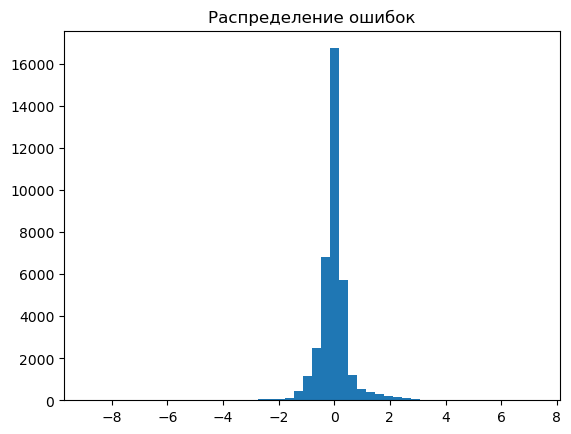

In [115]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

In [129]:
grid_model.best_params_

{'alpha': 0.0009, 'l1_ratio': 1}

#### Без нулевого пика

In [170]:
df_without_zero = df[df["peak_ccu"] > 0]
df_without_zero

,required_age,price,dlc_count,metacritic_score,supported_languages,full_audio_languages,positive,negative,median_playtime_forever,median_playtime_2weeks,...,dev_'HostedGames',dev_'LaushDmitriySergeevich',pub_'8floor',pub_'BFGEntertainment',pub_'ChoiceofGames',pub_'Conglomerate5',pub_'HH-Games',pub_'Hede',pub_'KaguraGames',pub_'StrategyFirst'
3,0,2.301585,1,0,1,1,0.000000,0.000000,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
6,0,3.610648,1,0,1,0,4.770685,2.639057,7.134094,0.000000,...,False,False,False,False,False,False,False,False,False,False
9,0,0.463734,1,0,30,0,2.995732,1.945910,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
12,0,2.707383,4,80,6,0,6.933423,5.351858,3.970292,0.000000,...,False,False,False,False,False,False,False,False,False,False
19,0,1.944481,0,0,18,2,0.000000,0.000000,4.574711,0.000000,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122520,0,2.301585,0,0,4,0,3.761200,2.564949,0.000000,0.000000,...,False,False,True,False,False,False,False,False,False,False
122537,0,1.249902,0,0,1,0,7.410952,4.634729,3.178054,8.754476,...,False,False,False,False,False,False,False,False,False,False
122543,0,1.747459,1,0,8,0,5.361292,3.713572,4.521789,0.000000,...,False,False,False,False,False,False,False,False,False,False
122553,0,1.848455,0,0,13,0,8.087333,5.913503,5.484797,0.000000,...,False,False,False,False,False,False,False,False,False,False


In [209]:
X = df_without_zero.drop(["peak_ccu"], axis=1)
y = df_without_zero["peak_ccu"]

In [210]:
X_ = X.drop(["pub_'Hede'"], axis=1)
X.columns

Index(['required_age', 'price', 'dlc_count', 'metacritic_score',
       'supported_languages', 'full_audio_languages', 'positive', 'negative',
       'median_playtime_forever', 'median_playtime_2weeks', 'release_month',
       'days_since_release', 'estimated_owners_avg', 'percent_positive',
       'name_pca_0', 'name_pca_1', 'name_pca_2', 'name_pca_3', 'name_pca_4',
       'name_pca_5', 'name_pca_6', 'name_pca_7', 'name_pca_8', 'name_pca_9',
       'name_pca_10', 'name_pca_11', 'name_pca_12', 'name_pca_13',
       'name_pca_14', 'name_pca_15', 'name_pca_16', 'name_pca_17',
       'name_pca_18', 'name_pca_19', 'name_pca_20', 'name_pca_21',
       'name_pca_22', 'name_pca_23', 'name_pca_24', 'name_pca_25',
       'name_pca_26', 'name_pca_27', 'name_pca_28', 'name_pca_29',
       'name_pca_30', 'name_pca_31', 'desc_pca_0', 'desc_pca_1', 'desc_pca_2',
       'desc_pca_3', 'desc_pca_4', 'genre_Indie', 'genre_Casual',
       'genre_Action', 'genre_Adventure', 'genre_Simulation',
       'cat

In [211]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [212]:
from sklearn.linear_model import ElasticNet
base_elastic_model = ElasticNet()

In [213]:
param_grid = {"alpha":[i/10000 for i in range(10)],
               "l1_ratio":[0.1, 0.5, 0.7, 0.95, 0.99, 1]}

In [214]:
from sklearn.model_selection import  GridSearchCV
grid_model = GridSearchCV(base_elastic_model, param_grid=param_grid, scoring = "neg_mean_squared_error", cv = 5, verbose = 0)

In [215]:
grid_model.fit(X_train, y_train)

c:\Users\danil\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.636e+03, tolerance: 3.470e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinat

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005,
                                   0.0006, 0.0007, 0.0008, 0.0009],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error')

In [216]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [217]:
y_pred = grid_model.predict(X_test)

In [218]:
MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print(f"MAE:{MAE}, MSE:{MSE}, RMSE:{RMSE}, R^2:{R2}")

MAE:0.7588887987045989, MSE:1.0271537758711171, RMSE:1.0134859524784332, R^2:0.666728158601485


In [219]:
grid_model.best_params_

{'alpha': 0.0009, 'l1_ratio': 1}

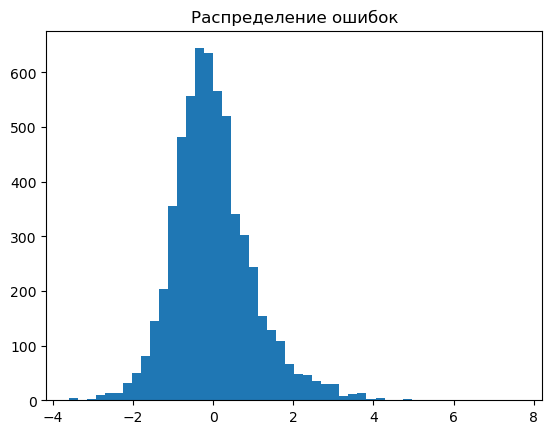

In [220]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

#### Свои данные

In [235]:
df_necesse = preprocessing(df_necesse)

df_name_emd = transformer_name(df_necesse["name"])
df_desc_emd = transformer_desc(df_necesse["short_description"])
df_necesse = pd.concat([df_necesse, df_name_emd, df_desc_emd], axis=1)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [238]:

necesse_data = {
    'required_age': 0,
    'price': 9.99, 
    'dlc_count': 0,
    'metacritic_score': 0, 
    'supported_languages': 14, 
    'full_audio_languages': 1,  
    'positive': 18500,
    'negative': 600,
    'median_playtime_forever': 680, 
    'median_playtime_2weeks': 45,
    'release_month': 12, 
    'days_since_release': 2300, 
    'estimated_owners_avg': 750000, 
    'percent_positive': 0.968, 
    
    **{f'name_pca_{i}': df_necesse[f"name_pca_{i}"] for i in range(32)},
    **{f'desc_pca_{i}': df_necesse[f"desc_pca_{i}"] for i in range(5)},
    
    'genre_Indie': 1,
    'genre_Casual': 0,
    'genre_Action': 1,
    'genre_Adventure': 1,
    'genre_Simulation': 0,
    
    'cat_Single-player': 1,
    'cat_Family Sharing': 1,
    'cat_Steam Achievements': 1,
    'cat_Steam Cloud': 1,
    'cat_Full controller support': 0, 
    
    "dev_'BoogygamesStudios'": 0, "dev_'BullyRevengeStudios'": 0, "dev_'Creobit'": 0,
    "dev_'CyberKeks'": 0, "dev_'EroticGamesClub'": 0, "dev_'Gamesforgames'": 0,
    "dev_'HostedGames'": 0, "dev_'LaushDmitriySergeevich'": 0,
    
    "pub_'8floor'": 0, "pub_'BFGEntertainment'": 0, "pub_'ChoiceofGames'": 0,
    "pub_'Conglomerate5'": 0, "pub_'HH-Games'": 0, "pub_'Hede'": 0,
    "pub_'KaguraGames'": 0, "pub_'StrategyFirst'": 0
}

df_necesse_final = pd.DataFrame([necesse_data])

In [242]:
df_necesse_final["median_playtime_forever"] = np.log1p(df_necesse_final["median_playtime_forever"])
df_necesse_final["median_playtime_2weeks"] = np.log1p(df_necesse_final["median_playtime_2weeks"])
df_necesse_final["price"] = np.log1p(df_necesse_final["price"])
df_necesse_final["positive"] = np.log1p(df_necesse_final["positive"])
df_necesse_final["negative"] = np.log1p(df_necesse_final["negative"])


In [243]:
X_nes = scaler.transform(df_necesse_final)

c:\Users\danil\anaconda3\Lib\site-packages\sklearn\utils\_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)


In [244]:
grid_model.predict(X_nes)

array([4.38631549])

## Разделяем и потом преобразуем

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv("../Data/2_lab.csv", index_col=False)

In [7]:
df = preprocessing(df)
df = df[df["price"] <= 200]
df = df[df["dlc_count"] <= 100]

In [8]:
X = df.drop(["peak_ccu"], axis=1)
y = df["peak_ccu"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [10]:
transformer_name = get_pca_embeddings(model, X_train["name"], 32, "name")
transformer_desc = get_pca_embeddings(model, X_train["short_description"], 5, "desc")

Batches:   0%|          | 0/1341 [00:00<?, ?it/s]

Batches:   0%|          | 0/1341 [00:00<?, ?it/s]

In [12]:
x_name_emd = transformer_name(X_train ["name"])
x_desc_emd = transformer_desc(X_train["short_description"])
X_train = pd.concat([X_train, x_name_emd, x_desc_emd], axis=1)

x_name_emd_t = transformer_name(X_test["name"])
x_desc_emd_t = transformer_desc(X_test["short_description"])
X_test = pd.concat([X_test, x_name_emd_t, x_desc_emd_t], axis=1)

Batches:   0%|          | 0/575 [00:00<?, ?it/s]

Batches:   0%|          | 0/575 [00:00<?, ?it/s]

In [13]:
X_train = X_train.drop(["name", "short_description"], axis=1)
X_test = X_test.drop(["name", "short_description"], axis=1)

In [14]:
X_test.columns

Index(['required_age', 'price', 'dlc_count', 'metacritic_score',
       'metacritic_url', 'supported_languages', 'full_audio_languages',
       'developers', 'publishers', 'categories', 'genres', 'positive',
       'negative', 'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'release_year',
       'release_month', 'days_since_release', 'estimated_owners_avg',
       'percent_positive', 'name_pca_0', 'name_pca_1', 'name_pca_2',
       'name_pca_3', 'name_pca_4', 'name_pca_5', 'name_pca_6', 'name_pca_7',
       'name_pca_8', 'name_pca_9', 'name_pca_10', 'name_pca_11', 'name_pca_12',
       'name_pca_13', 'name_pca_14', 'name_pca_15', 'name_pca_16',
       'name_pca_17', 'name_pca_18', 'name_pca_19', 'name_pca_20',
       'name_pca_21', 'name_pca_22', 'name_pca_23', 'name_pca_24',
       'name_pca_25', 'name_pca_26', 'name_pca_27', 'name_pca_28',
       'name_pca_29', 'name_pca_30', 'name_pca_31', 'desc_pca_0', 'desc_pca_1'

### Обработка оставшихся данных (уже без утечки данных)

In [15]:
X_train["genres"]

18813                      ['Adventure', 'Casual', 'Indie']
43543                     ['Casual', 'Indie', 'Simulation']
22998                   ['Action', 'Indie', 'Free To Play']
111572        ['Action', 'Indie', 'Simulation', 'Strategy']
86816                                   ['Casual', 'Indie']
                                ...                        
5698                       ['Action', 'Adventure', 'Indie']
73570                        ['Action', 'Adventure', 'RPG']
83319                               ['Adventure', 'Casual']
83505                         ['Adventure', 'Free To Play']
45938     ['Adventure', 'Indie', 'Simulation', 'Free To ...
Name: genres, Length: 85785, dtype: object

In [16]:
X_train["genres"] = X_train["genres"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
X_test["genres"] = X_test["genres"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
top_five = X_train['genres'].explode().value_counts().nlargest(5).index.to_list()

In [17]:
for genre in top_five:  
    X_train[f'genre_{genre}'] = X_train['genres'].apply(lambda x: 1 if genre in x else 0)

for genre in top_five:
    X_test[f"genre_{genre}"] = X_test["genres"].apply(lambda x: 1 if genre in x else 0)

In [18]:
X_train["categories"] = X_train["categories"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
X_test["categories"] = X_test["categories"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
top_five = X_train['categories'].explode().value_counts().nlargest(5).index.to_list()

In [19]:
for cat in top_five:  
    X_train[f'cat_{cat}'] = X_train['categories'].apply(lambda x: 1 if cat in x else 0)

for cat in top_five:
    X_test[f"cat_{cat}"] = X_test["categories"].apply(lambda x: 1 if cat in x else 0)

In [20]:
X_test.columns

Index(['required_age', 'price', 'dlc_count', 'metacritic_score',
       'metacritic_url', 'supported_languages', 'full_audio_languages',
       'developers', 'publishers', 'categories', 'genres', 'positive',
       'negative', 'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'release_year',
       'release_month', 'days_since_release', 'estimated_owners_avg',
       'percent_positive', 'name_pca_0', 'name_pca_1', 'name_pca_2',
       'name_pca_3', 'name_pca_4', 'name_pca_5', 'name_pca_6', 'name_pca_7',
       'name_pca_8', 'name_pca_9', 'name_pca_10', 'name_pca_11', 'name_pca_12',
       'name_pca_13', 'name_pca_14', 'name_pca_15', 'name_pca_16',
       'name_pca_17', 'name_pca_18', 'name_pca_19', 'name_pca_20',
       'name_pca_21', 'name_pca_22', 'name_pca_23', 'name_pca_24',
       'name_pca_25', 'name_pca_26', 'name_pca_27', 'name_pca_28',
       'name_pca_29', 'name_pca_30', 'name_pca_31', 'desc_pca_0', 'desc_pca_1'

In [21]:
X_train["developers"] = X_train["developers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
X_test["developers"] = X_test["developers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
top_ten = X_train['developers'].explode().value_counts().nlargest(10).index.to_list()

In [22]:
for dev in top_ten:  
    X_train[f'dev_{dev}'] = X_train['developers'].apply(lambda x: 1 if dev in x else 0)

for dev in top_ten:
    X_test[f"dev_{dev}"] = X_test["developers"].apply(lambda x: 1 if dev in x else 0)

In [23]:
X_train["publishers"] = X_train["publishers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
X_test["publishers"] = X_test["publishers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
top_ten = X_train['publishers'].explode().value_counts().nlargest(10).index.to_list()

In [24]:
for pub in top_ten:  
    X_train[f'pub_{pub}'] = X_train['publishers'].apply(lambda x: 1 if pub in x else 0)

for pub in top_ten:
    X_test[f"pub_{pub}"] = X_test["publishers"].apply(lambda x: 1 if pub in x else 0)

In [25]:
X_train = X_train.drop(["developers", "publishers", "genres", "categories"], axis=1)
X_test = X_test.drop(["developers", "publishers", "genres", "categories"], axis=1)

In [26]:
X_train.columns == X_test.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

### Кореляционный анализ

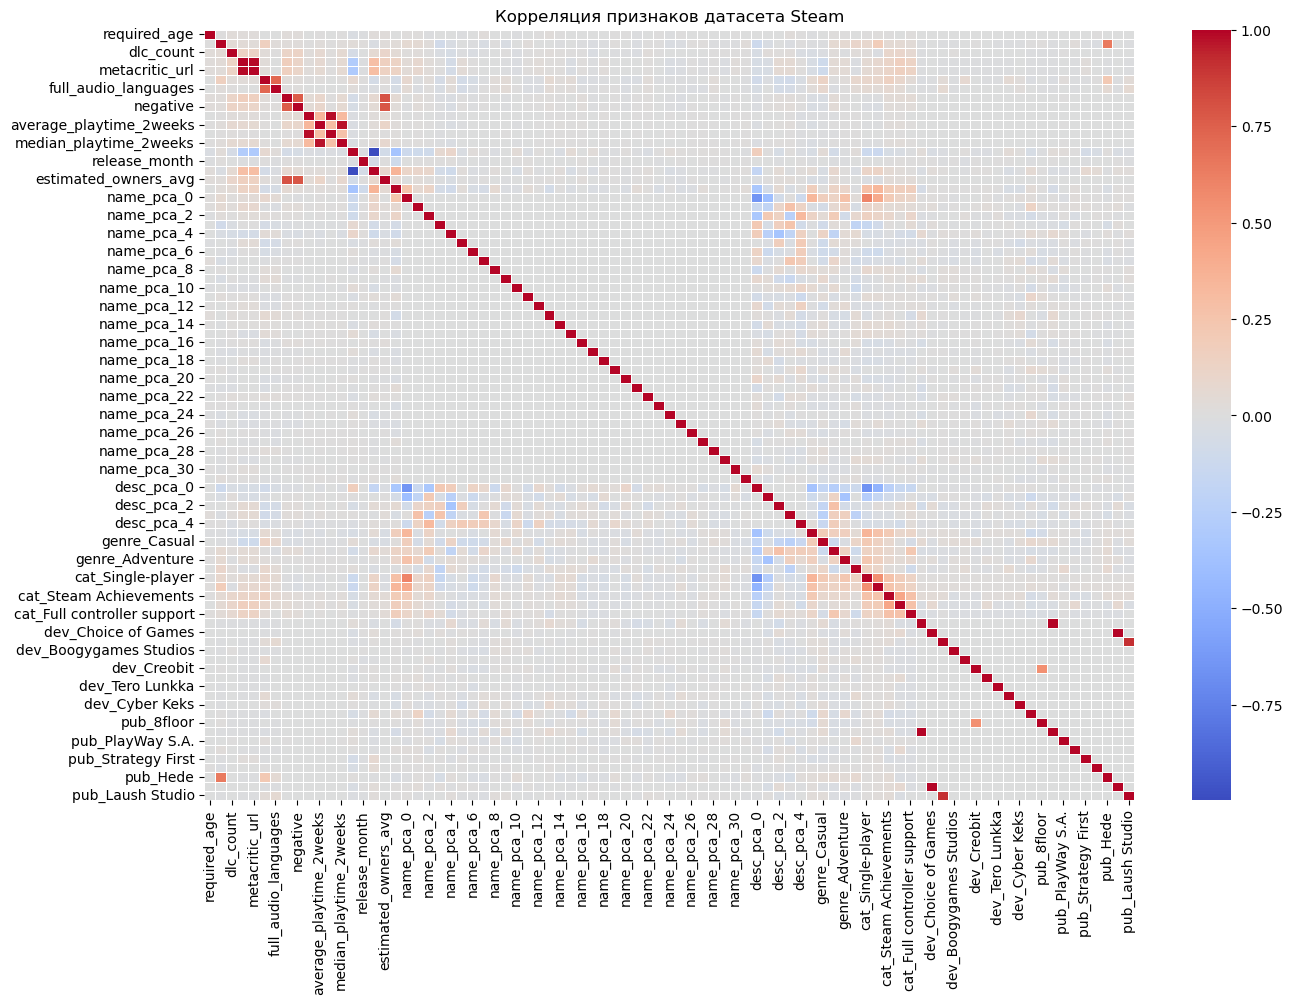

In [27]:
corr_matrix = X_train.corr()

plt.figure(figsize=(15, 10))

sns.heatmap(
    corr_matrix, 
    annot=False,       
    cmap='coolwarm',   
    center=0,          
    fmt='.2f',         
    linewidths=0.5  
)

plt.title('Корреляция признаков датасета Steam')
plt.show()

In [34]:
X_train = X_train.drop(["metacritic_url"], axis=1)
X_test = X_test.drop(["metacritic_url"], axis=1)


KeyError: "['metacritic_url'] not found in axis"

In [35]:
corr_matrix["average_playtime_2weeks"].nlargest(5)

average_playtime_2weeks     1.000000
median_playtime_2weeks      0.973377
average_playtime_forever    0.341795
median_playtime_forever     0.293749
estimated_owners_avg        0.110074
Name: average_playtime_2weeks, dtype: float64

In [36]:
corr_matrix["average_playtime_forever"].nlargest(5)

average_playtime_forever    1.000000
median_playtime_forever     0.981708
average_playtime_2weeks     0.341795
median_playtime_2weeks      0.317353
positive                    0.044805
Name: average_playtime_forever, dtype: float64

In [37]:
X_train = X_train.drop(["average_playtime_forever", "average_playtime_2weeks"], axis=1)
X_test = X_test.drop(["average_playtime_forever", "average_playtime_2weeks"], axis=1)

KeyError: "['average_playtime_forever', 'average_playtime_2weeks'] not found in axis"

In [38]:
corr_matrix["positive"].nlargest(10)

positive                   1.000000
estimated_owners_avg       0.801379
negative                   0.762005
metacritic_score           0.170639
metacritic_url             0.151514
dlc_count                  0.114917
average_playtime_2weeks    0.094857
days_since_release         0.066757
median_playtime_2weeks     0.057480
percent_positive           0.049497
Name: positive, dtype: float64

In [39]:
corr_matrix["days_since_release"].nsmallest(10)

release_year                -0.996262
desc_pca_0                  -0.171001
name_pca_4                  -0.099247
name_pca_3                  -0.071946
supported_languages         -0.067226
release_month               -0.066244
name_pca_15                 -0.044085
name_pca_10                 -0.038068
genre_Casual                -0.037086
dev_Bully Revenge Studios   -0.034154
Name: days_since_release, dtype: float64

In [40]:
X_train = X_train.drop(["release_year"], axis=1)
X_test = X_test.drop(["release_year"], axis=1)

In [41]:
len(X_train.columns)

81

In [36]:
corr_matrix["pub_EroticGamesClub"].nlargest(10)

dev_EroticGamesClub       1.000000
pub_EroticGamesClub       1.000000
name_pca_13               0.071081
name_pca_4                0.071023
genre_Casual              0.052896
name_pca_25               0.048496
name_pca_9                0.042589
name_pca_29               0.042253
name_pca_7                0.034502
cat_Steam Achievements    0.033297
Name: pub_EroticGamesClub, dtype: float64

In [42]:
X_train = X_train.drop(["pub_EroticGamesClub"], axis=1)
X_test = X_test.drop(["pub_EroticGamesClub"], axis=1)

In [38]:
corr_matrix["median_playtime_forever"].nlargest(10)

median_playtime_forever     1.000000
average_playtime_forever    0.981708
average_playtime_2weeks     0.293749
median_playtime_2weeks      0.271003
days_since_release          0.014109
dlc_count                   0.012119
percent_positive            0.011618
cat_Steam Achievements      0.009594
name_pca_18                 0.009226
cat_Steam Cloud             0.009101
Name: median_playtime_forever, dtype: float64

In [43]:
corr_matrix["release_month"].nlargest(10)

release_month             1.000000
name_pca_4                0.016541
price                     0.015387
name_pca_11               0.011112
name_pca_16               0.010878
cat_Steam Cloud           0.010516
dev_Choice of Games       0.009525
pub_Choice of Games       0.009525
name_pca_19               0.009357
cat_Steam Achievements    0.009141
Name: release_month, dtype: float64

In [44]:
X_train = X_train.drop(["positive","negative"], axis=1)
X_test = X_test.drop(["positive","negative"], axis=1)

In [46]:
print(len(X_train.columns))
X_train.columns

78


Index(['required_age', 'price', 'dlc_count', 'metacritic_score',
       'supported_languages', 'full_audio_languages',
       'median_playtime_forever', 'median_playtime_2weeks', 'release_month',
       'days_since_release', 'estimated_owners_avg', 'percent_positive',
       'name_pca_0', 'name_pca_1', 'name_pca_2', 'name_pca_3', 'name_pca_4',
       'name_pca_5', 'name_pca_6', 'name_pca_7', 'name_pca_8', 'name_pca_9',
       'name_pca_10', 'name_pca_11', 'name_pca_12', 'name_pca_13',
       'name_pca_14', 'name_pca_15', 'name_pca_16', 'name_pca_17',
       'name_pca_18', 'name_pca_19', 'name_pca_20', 'name_pca_21',
       'name_pca_22', 'name_pca_23', 'name_pca_24', 'name_pca_25',
       'name_pca_26', 'name_pca_27', 'name_pca_28', 'name_pca_29',
       'name_pca_30', 'name_pca_31', 'desc_pca_0', 'desc_pca_1', 'desc_pca_2',
       'desc_pca_3', 'desc_pca_4', 'genre_Indie', 'genre_Casual',
       'genre_Action', 'genre_Adventure', 'genre_Simulation',
       'cat_Single-player', 'cat_Fa

#### Логармирование

In [47]:
X_train["median_playtime_2weeks"] = np.log1p(X_train["median_playtime_2weeks"])
X_train["median_playtime_forever"] = np.log1p(X_train["median_playtime_forever"])

X_test["median_playtime_2weeks"] = np.log1p(X_test["median_playtime_2weeks"])
X_test["median_playtime_forever"] = np.log1p(X_test["median_playtime_forever"])

In [48]:
X_train["estimated_owners_avg"] = np.log1p(X_train["estimated_owners_avg"])
X_test["estimated_owners_avg"] = np.log1p(X_test["estimated_owners_avg"])

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

### Обучение


#### C нулевым пиком

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_ = scaler.transform(X_train)
X_test_ = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import ElasticNet
base_elastic_model = ElasticNet()

param_grid = {"alpha":[i/10000 for i in range(10)],
               "l1_ratio":[0.1, 0.5, 0.7, 0.95, 0.99, 1]}

In [45]:
from sklearn.model_selection import  GridSearchCV
grid_model = GridSearchCV(base_elastic_model, param_grid=param_grid, scoring = "neg_mean_squared_error", cv = 5, verbose = 0)

In [46]:
grid_model.fit(X_train_, y_train)

c:\Users\danil\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.598e+04, tolerance: 7.470e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinat

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005,
                                   0.0006, 0.0007, 0.0008, 0.0009],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error')

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = grid_model.predict(X_test_)

MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print(f"MAE:{MAE}, MSE:{MSE}, RMSE:{RMSE}, R^2:{R2}")

MAE:0.36283758751099543, MSE:0.4592827924007767, RMSE:0.6777040596018122, R^2:0.5605270582714421


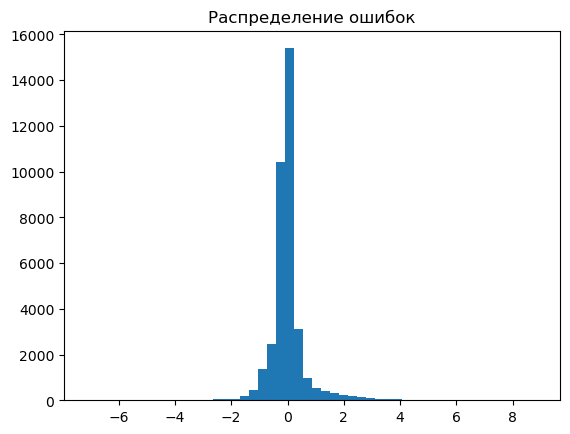

In [48]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

#### Без нулевого пика

In [49]:
mask_train = y_train > 0
X_train__ = X_train[mask_train]
y_train__ = y_train[mask_train]

mask_test = y_test > 0
X_test__ = X_test[mask_test]
y_test__ = y_test[mask_test]

In [ ]:
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#scaler.fit(X_train__)
#X_train__ = scaler.transform(X_train__)
#X_test__ = scaler.transform(X_test__)

In [102]:
# начинать отсюда
from sklearn.linear_model import ElasticNet
base_elastic_model = ElasticNet()

param_grid = {"alpha":[i/10000 for i in range(10)],
               "l1_ratio":[0.1, 0.5, 0.7, 0.95, 0.99, 1]}

In [103]:
from sklearn.model_selection import  GridSearchCV
grid_model = GridSearchCV(base_elastic_model, param_grid=param_grid, scoring = "neg_mean_squared_error", cv = 5, verbose = 0)

In [104]:
grid_model.fit(X_train, y_train)

c:\Users\danil\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.019e+03, tolerance: 3.470e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinat

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005,
                                   0.0006, 0.0007, 0.0008, 0.0009],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error')

In [105]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = grid_model.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)
MAE = mean_absolute_error(y_pred, y_test)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print(f"MAE:{MAE}, MSE:{MSE}, RMSE:{RMSE}, R^2:{R2}")

MAE:0.7712580116349336, MSE:1.0999335426411934, RMSE:1.0487771653889082, R^2:0.6431139272587174


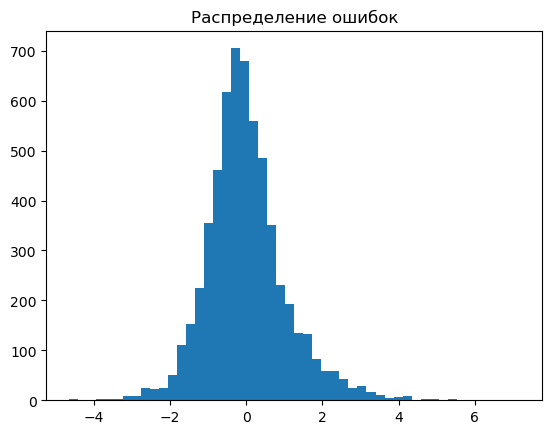

In [106]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('Распределение ошибок')
plt.show()

In [107]:
grid_model.best_estimator_

ElasticNet(alpha=0.0009, l1_ratio=1)

## Авто обработка

In [7]:
df = pd.read_csv("../Data/2_lab.csv", index_col=False)

tuple_values = full_preprocessing(df)

Batches:   0%|          | 0/215 [00:00<?, ?it/s]

Batches:   0%|          | 0/215 [00:00<?, ?it/s]

Batches:   0%|          | 0/93 [00:00<?, ?it/s]

Batches:   0%|          | 0/93 [00:00<?, ?it/s]

In [8]:
import joblib
save_data = tuple_values[:4]

In [10]:
joblib.dump(save_data, '../Data/preprocessing_all_info.joblib')

['../Data/preprocessing_all_info.joblib']